# Import

In [25]:
import rich
import logging
import glob
import matplotlib.pyplot as plt
import time
import re
import os
import awkward as ak
import numpy as np
import pandas as pd
import json 
import yaml
import dbetto
import lh5
from copy import deepcopy
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data
from tqdm import tqdm
from scipy.stats import ks_2samp
from scipy.spatial.distance import jensenshannon
from pathlib import Path
from collections import defaultdict
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.patches import Rectangle, ConnectionPatch
import matplotlib as mpl
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec


import pygeomhades
import pygeomtools
from pygeomtools import write_pygeom
import pyg4ometry as pg4
from pyg4ometry import gdml

%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)

# functions


In [2]:
import reboost
from reboost import hpge
from reboost.hpge import surface, psd
from reboost.shape import group
from reboost.math import functions
from reboost.math.stats import gaussian_sample
from reboost.utils import get_remage_detector_uids




# Function

In [3]:
from scipy.stats import truncnorm
def sample_truncated_gaussian(mu, sigma, size=1):
    a = (0 - mu) / sigma
    b = np.inf

    return truncnorm.rvs(
        a,
        b,
        loc=mu,
        scale=sigma,
        size=size
    )

In [4]:







def generic_polycone_profile(solid):
    r = np.asarray(
        solid.evaluateParameterWithUnits("pR"),
        dtype=float
    )
    z = np.asarray(
        solid.evaluateParameterWithUnits("pZ"),
        dtype=float
    )

    return np.append(r, r[0]), np.append(z, z[0])


def polycone_profile(solid):
    z = np.asarray(
        solid.evaluateParameterWithUnits("pZpl"),
        dtype=float
    )
    rmin = np.asarray(
        solid.evaluateParameterWithUnits("pRMin"),
        dtype=float
    )
    rmax = np.asarray(
        solid.evaluateParameterWithUnits("pRMax"),
        dtype=float
    )

    r = np.concatenate([rmax, rmin[::-1], [rmax[0]]])
    z = np.concatenate([z, z[::-1], [z[0]]])

    return r, z

    
def get_profile(solid):
    solid_type = str(solid.type).lower()

    if "genericpolycone" in solid_type:
        return generic_polycone_profile(solid)

    if "polycone" in solid_type:
        return polycone_profile(solid)

    if "tubs" in solid_type or "tube" in solid_type:
        return tubs_profile(solid)

    if "box" in solid_type:
        return box_profile(solid)

    raise TypeError(
        f"Solido {solid.name} di tipo {solid.type} non supportato"
    )

def evaluate_vector(vector):
    """Converte Position o Rotation di pyg4ometry in array numerico."""
    return np.asarray(vector.eval(), dtype=float)


def physical_volume_matrix(pv):
    """Matrice omogenea della trasformazione del PhysicalVolume."""
    position = evaluate_vector(pv.position)
    rotation = evaluate_vector(pv.rotation)

    rotation_matrix = np.linalg.inv(
        pg4.transformation.tbxyz2matrix(rotation)
    )

    matrix = np.eye(4)
    matrix[:3, :3] = rotation_matrix
    matrix[:3, 3] = position

    return matrix


def collect_global_placements(logical_volume, parent_matrix=None):
    """
    Percorre ricorsivamente il GDML e restituisce la trasformazione
    globale di ogni volume fisico.
    """
    if parent_matrix is None:
        parent_matrix = np.eye(4)

    placements = {}

    def walk(mother_lv, mother_matrix):
        for pv in mother_lv.daughterVolumes:
            local_matrix = physical_volume_matrix(pv)
            global_matrix = mother_matrix @ local_matrix

            logical_name = pv.logicalVolume.name

            placements.setdefault(logical_name, []).append({
                "physical_name": pv.name,
                "logical_volume": pv.logicalVolume,
                "matrix": global_matrix,
            })

            walk(pv.logicalVolume, global_matrix)

    walk(logical_volume, parent_matrix)

    return placements


def find_germanium_detector(reg):
    candidates = []

    for name, lv in reg.logicalVolumeDict.items():
        material_name = getattr(lv.material, "name", str(lv.material))

        if "Germanium" in material_name:
            candidates.append(name)

    if len(candidates) == 0:
        raise ValueError("Nessun detector al germanio trovato")

    if len(candidates) > 1:
        print("Detector al germanio trovati:", candidates)

    return candidates[0]



def find_source(reg):
    candidates = []

    for name, lv in reg.logicalVolumeDict.items():
        material_name = getattr(lv.material, "name", str(lv.material))

        if "Source" in material_name:
            candidates.append(name)

    if len(candidates) == 0:
        raise ValueError("Nessuna sorgente trovate")

    if len(candidates) > 1:
        print("Sorgente trovata:", candidates)

    return candidates[0]

def tubs_profile(solid):
    """Profilo r-z di un cilindro Tubs."""

    rmin = float(solid.evaluateParameterWithUnits("pRMin"))
    rmax = float(solid.evaluateParameterWithUnits("pRMax"))
    dz = float(solid.evaluateParameterWithUnits("pDz"))

    # pDz è la lunghezza totale lungo z
    zmin = -dz / 2
    zmax = dz / 2

    r = np.array([
        rmin,
        rmax,
        rmax,
        rmin,
        rmin
    ])

    z = np.array([
        zmin,
        zmin,
        zmax,
        zmax,
        zmin
    ])

    return r, z

def box_profile(solid):
    """Profilo nel piano locale x-z di un Box."""

    size_x = float(solid.evaluateParameterWithUnits("pX"))
    size_z = float(solid.evaluateParameterWithUnits("pZ"))

    xmin = -size_x / 2
    xmax = size_x / 2
    zmin = -size_z / 2
    zmax = size_z / 2

    r = np.array([
        xmin,
        xmax,
        xmax,
        xmin,
        xmin
    ])

    z = np.array([
        zmin,
        zmin,
        zmax,
        zmax,
        zmin
    ])

    return r, z

def transform_profile(r, z, matrix):
    """
    Trasforma un profilo locale (r, z) nelle coordinate globali.

    Parameters
    ----------
    r : array-like
        Coordinate radiali locali.
    z : array-like
        Coordinate verticali locali.
    matrix : array-like, shape (4, 4)
        Matrice omogenea contenente rotazione e traslazione globali.

    Returns
    -------
    radius : ndarray
        Distanza globale dall'asse z.
    height : ndarray
        Coordinata z globale.
    """

    r = np.asarray(r, dtype=float)
    z = np.asarray(z, dtype=float)

    # Punti omogenei locali: (x=r, y=0, z, 1)
    points = np.column_stack([
        r,
        np.zeros_like(r),
        z,
        np.ones_like(r)
    ])

    # Trasformazione nelle coordinate globali
    transformed = (matrix @ points.T).T

    x_global = transformed[:, 0]
    y_global = transformed[:, 1]
    z_global = transformed[:, 2]

    radius = np.sqrt(x_global**2 + y_global**2)
    height = z_global
    
    return radius, height


# Metadata

In [5]:
detector = "V03421A"
run = "r001"
version = "v1.2.1"
measure = "th_HS2_top_psa"

In [6]:
metadata_path = "/global/u2/r/ritaferi/HADES_DATA/hades-metadata"
output_dir = "/global/u2/r/ritaferi/HADES_DATA"
gdml_file = os.path.join(
    output_dir,
    f"{detector}_{measure}_run0001.gdml"
)

In [7]:
db = dbetto.TextDB(metadata_path)

In [12]:
configuration = db.hardware.configuration[detector]["c1"][measure]
time_measurement = configuration['run0001']['run_live_time_in_s']#["run_live_time_in_s"]
time_bkg = (
    db.hardware.configuration[detector]["c1"]["bkg"]["run0001"]
    ["run_live_time_in_s"]
)

print(f'Time measurement : {time_measurement} s')
print(f'Time Background : {time_bkg} s')

Time measurement : 21600 s
Time Background : 61200 s


# DATA

In [13]:


measurement_files = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/{version}//generated/tier/hit/{detector}/c1/*"
))

print(*measurement_files, sep="\n")

/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03421A/c1/am_HS1_lat_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03421A/c1/am_HS1_lat_ssh
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03421A/c1/am_HS1_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03421A/c1/am_HS1_top_ssh
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03421A/c1/am_HS6_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03421A/c1/am_HS6_top_hvs
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03421A/c1/ba_HS4_top_dlt
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03421A/c1/bkg
/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.2.1//generated/tier/hit/V03421A/c1/co_HS5_top_hvs
/global/cfs/

In [14]:
measurements = [
    os.path.basename(path)
    for path in measurement_files
]
print(*measurements, sep="\n")

am_HS1_lat_dlt
am_HS1_lat_ssh
am_HS1_top_dlt
am_HS1_top_ssh
am_HS6_top_dlt
am_HS6_top_hvs
ba_HS4_top_dlt
bkg
co_HS5_top_hvs
th_HS2_lat_psa
th_HS2_top_psa


In [15]:
file_names = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/{version}//generated/tier/hit/{detector}/c1/{measure}/char_data-{detector}-{measure}-*.lh5"
))
file_names_bkg = sorted(glob.glob(
    f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/{version}/generated/tier/hit/{detector}/c1/bkg/char_data-{detector}-bkg-r001-*.lh5"
    #f"/global/cfs/cdirs/m2676/data/teststands/hades/prodenv/ref/v1.1.0/generated/tier/hit/V03422A/c1/bkg"
))

In [16]:
bkg = lh5.read("hit", file_names_bkg)
df_bkg =  bkg.view_as("pd") 

In [17]:
data = lh5.read("hit", file_names)
df = data.view_as("pd")
df.head();

In [18]:
alpha = time_measurement / time_bkg

print("\nNormalizzazione")
print(f"Tempo misura: {time_measurement:.2f} s")
print(f"Tempo background: {time_bkg:.2f} s")
print(f"Alpha: {alpha:.6f}")


Normalizzazione
Tempo misura: 21600.00 s
Tempo background: 61200.00 s
Alpha: 0.352941


In [19]:
# Stessi bin per tutti
emin = 0
emax = 3500
nbins = 350

# Bordi comuni
bins = np.linspace(
    emin,
    emax,
    nbins + 1
)

In [20]:
# spettro dato misurati
counts_data, _ = np.histogram(
    df["cuspEmax_ctc_cal"],
    bins=bins
)

# conteggio bkg normlaizzato all'esposizione della sorgente
counts_bkg, _ = np.histogram(
    df_bkg["cuspEmax_ctc_cal"],
    bins=bins,
    weights = np.full(len(df_bkg["cuspEmax_ctc_cal"]), alpha)
)



(-50.0, 3500.0)

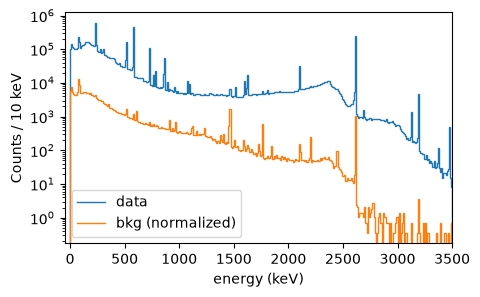

In [21]:
plt.figure(figsize=(5,3))
plt.stairs(counts_data, bins, label = 'data')
plt.stairs(counts_bkg, bins, label = 'bkg (normalized)')
plt.yscale('log')
plt.ylabel(f'Counts / {bins[1]-bins[0]:.0f} keV')
plt.xlabel("energy (keV)")
plt.legend()
plt.xlim(-50,3500)

# simulation

In [26]:
run = "run0001"
config_geom = deepcopy(configuration[run])

gdml_file = os.path.join(
    output_dir, f"{detector}_{measure}_{run}.gdml"
)

if os.path.isfile(gdml_file):
    reg = gdml.Reader(gdml_file).getRegistry()
    print(f"GDML già presente, caricato: {gdml_file}")
else:
    reg = pygeomhades.core.construct(config_geom)
    os.makedirs(output_dir, exist_ok=True)
    write_pygeom(reg, gdml_file)
    print(f"GDML creato: {gdml_file}")

INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Reader:Reader.load>
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define TWOPI
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define wrap_top_thickness
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define wrap_z
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define wrap_cavity_radius
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define wrap_radius
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define TWOPI_1
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define edge_height
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define pos_top_ring_z
INFO:pyg4ometry.gdml.Writer:gdml.Writer.addDetector> define end_top_ring_z
INFO:pyg4ometry.gdm

GDML creato: /global/u2/r/ritaferi/HADES_DATA/V03421A_th_HS2_top_psa_run0001.gdml


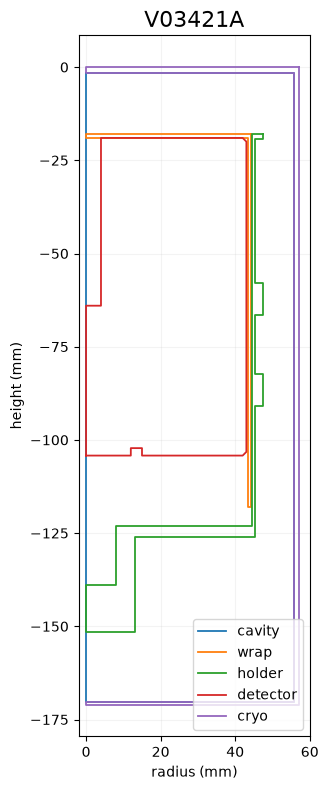

In [27]:

placements = collect_global_placements(reg.getWorldVolume())

detector_name = find_germanium_detector(reg)

components = {
    "cavity_lv": {
        "label": "cavity",
        "color": "tab:blue"
    },
    "Wrap": {
        "label": "wrap",
        "color": "tab:orange"
    },
    "Holder": {
        "label": "holder",
        "color": "tab:green"
    },
    detector_name: {
        "label": "detector",
        "color": "tab:red"
    },
    "Cryostat": {
        "label": "cryo",
        "color": "tab:purple"
    },
}

fig, ax = plt.subplots(figsize=(4,8))

for logical_name, style in components.items():

    if logical_name not in placements:
        print(f"Volume non trovato: {logical_name}")
        continue

    # Se esistono più copie, le disegna tutte
    for index, placement in enumerate(placements[logical_name]):

        lv = placement["logical_volume"]
        matrix = placement["matrix"]

        try:
            r_local, z_local = get_profile(lv.solid)
        except TypeError as error:
            print(error)
            continue

        radius, height = transform_profile(
            r_local,
            z_local,
            matrix
        )

        # Una sola voce in legenda per componente
        label = style["label"] if index == 0 else None

        ax.plot(
            radius,
            height,
            color=style["color"],
            linewidth=1.3,
            label=label
        )

ax.set_title(detector_name, fontsize=16)
ax.set_xlabel("radius (mm)")
ax.set_ylabel("height (mm)")

ax.set_xlim(left=-2)
ax.set_aspect("equal", adjustable="box")

ax.grid(alpha=0.15)
ax.legend(loc = 'lower right')

plt.tight_layout()
plt.show()

In [36]:
from remage import remage_run

isotopes = {
    "Pb212": {"Z": 82, "A": 212, "activity_factor": 1.0},
    "Bi212": {"Z": 83, "A": 212, "activity_factor": 1.0},
    "Tl208": {"Z": 81, "A": 208, "activity_factor": 0.3594},
}

N_sim = 10_000_000
force_rerun = False

# Usa detector, measure e gdml_file definiti nella cella precedente.
simulation_files = {}

for name, iso in isotopes.items():
    output_file = os.path.join(
        output_dir,
        f"{detector}_{measure}_{name}.lh5"
    )

    if os.path.isfile(output_file) and not force_rerun:
        simulation_files[name] = output_file
        print(f"✅ {name}: uso il file esistente → {output_file}")
        continue

    Z = iso["Z"]
    A = iso["A"]

    macro = [
        "/RMG/Manager/Logging/LogLevel summary",
        "/RMG/Processes/HadronicPhysics Shielding",
        f"/RMG/Geometry/RegisterDetector Germanium {detector} 1",
        "/RMG/Output/NtupleUseVolumeName true",
        "/RMG/Output/NtuplePerDetector false",
        "/run/initialize",
        "/RMG/Generator/Confine Volume",
        "/RMG/Generator/Confinement/Physical/AddVolume Source_PV",
        "/RMG/Generator/Select GPS",
        "/gps/particle ion",
        f"/gps/ion {Z} {A}",
        "/gps/energy 0 keV",
        f"/process/had/rdm/nucleusLimits {A} {A} {Z} {Z}",
        f"/run/beamOn {N_sim}",
    ]

    print(f"▶ {name}: avvio simulazione → {output_file}")

    try:
        remage_run(
            macros=macro,
            gdml_files=gdml_file,
            output=output_file,
            overwrite_output=True,
        )
        simulation_files[name] = output_file
        print(f"✅ {name}: simulazione completata")
    except Exception as e:
        print(f"❌ {name}: {e}")

print("\nFile disponibili:", simulation_files)

✅ Pb212: uso il file esistente → /global/u2/r/ritaferi/HADES_DATA/V03421A_th_HS2_top_psa_Pb212.lh5
✅ Bi212: uso il file esistente → /global/u2/r/ritaferi/HADES_DATA/V03421A_th_HS2_top_psa_Bi212.lh5
✅ Tl208: uso il file esistente → /global/u2/r/ritaferi/HADES_DATA/V03421A_th_HS2_top_psa_Tl208.lh5

File disponibili: {'Pb212': '/global/u2/r/ritaferi/HADES_DATA/V03421A_th_HS2_top_psa_Pb212.lh5', 'Bi212': '/global/u2/r/ritaferi/HADES_DATA/V03421A_th_HS2_top_psa_Bi212.lh5', 'Tl208': '/global/u2/r/ritaferi/HADES_DATA/V03421A_th_HS2_top_psa_Tl208.lh5'}


PATH: /global/u2/r/ritaferi/HADES_DATA/V03421A_th_HS2_top_psa_Pb212.lh5 | esiste: True
PATH: /global/u2/r/ritaferi/HADES_DATA/V03421A_th_HS2_top_psa_Bi212.lh5 | esiste: True
PATH: /global/u2/r/ritaferi/HADES_DATA/V03421A_th_HS2_top_psa_Tl208.lh5 | esiste: True


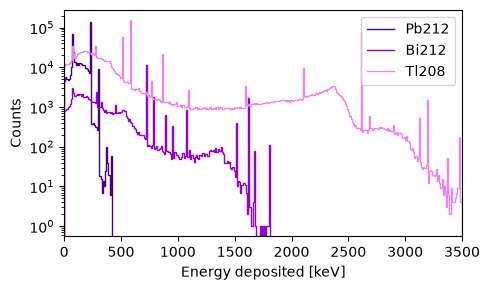

In [37]:
isotopes_to_plot = ["Pb212", "Bi212", "Tl208"]
colors = {
    "Pb212": "indigo",
    "Bi212": "darkviolet",
    "Tl208": "violet",
}

fig, ax = plt.subplots(figsize=(5, 3))#, dpi=300)
base = "/global/u2/r/ritaferi/HADES_DATA"
has_counts = False

for name in isotopes_to_plot:
    filename = os.path.join(base, f"{detector}_{measure}_{name}.lh5")
    print("PATH:", filename, "| esiste:", os.path.isfile(filename))

    try:
        data = lh5.read_as("stp/germanium", filename, "ak")
        energy = ak.to_numpy(ak.sum(data.edep, axis=-1))
        energy = energy[energy > 0]

        counts, _ = np.histogram(energy, bins=bins)

        if counts.sum() == 0:
            print(f"{name}: nessun deposito nell'intervallo del grafico")
            continue

        ax.stairs(counts, bins, color=colors[name], label=name)
        has_counts = True

    except Exception:
        print(f"Errore durante la lettura o il grafico di {name}:")
        traceback.print_exc()

if has_counts:
    ax.set_xlabel("Energy deposited [keV]")
    ax.set_ylabel("Counts")
    ax.set_xlim(emin, emax)
    ax.set_yscale("log")
    ax.legend()
    fig.tight_layout()
    plt.show()
else:
    plt.close(fig)
    print("Nessun conteggio da mostrare")

filename = f"{detector}_{measure}_run0001.lh5"

In [38]:
N_sim_by_iso = {}

for name in ["Pb212", "Bi212", "Tl208"]:
    filename = os.path.join(
        output_dir, f"{detector}_{measure}_{name}.lh5"
    )

    obj = lh5.read("number_of_simulated_events", filename)

    # Compatibilità con versioni che restituiscono una tupla
    if isinstance(obj, tuple):
        obj = obj[0]

    N_sim_by_iso[name] = int(obj.value)
    print(f"{name}: {N_sim_by_iso[name]:,} eventi simulati")

Pb212: 10,000,000 eventi simulati
Bi212: 10,000,000 eventi simulati
Tl208: 10,000,000 eventi simulati


In [39]:
BR = {
    "Pb212": 1.0,
    "Bi212": 1.0,
    "Tl208": 0.3594,
}

activity = 87e3  # Bq: valore nominale comune alla misura

counts_theory = np.zeros(len(bins) - 1)
counts_smeared = np.zeros(len(bins) - 1)

for name, br in BR.items():

    filename = os.path.join(
        output_dir, f"{detector}_{measure}_{name}.lh5"
    )

    # Gli errori di lettura vengono mostrati, evitando somme incomplete
    data = lh5.read_as("stp/germanium", filename, "ak")
    energy = ak.to_numpy(ak.sum(data.edep, axis=-1))
    energy = energy[energy > 0]

    if len(energy) == 0:
        print(f"{name}: nessun deposito positivo di energia")
        continue

    energy_smeared = ak.to_numpy(
        reboost.math.stats.gaussian_sample(energy, sigma=1)
    )

    N_sim = N_sim_by_iso[name]
    if N_sim <= 0:
        raise ValueError(f"{name}: N_sim deve essere positivo")

    # BR applicato una sola volta, nel peso
    peso = activity * time_measurement * br / N_sim
    weights = np.full(len(energy), peso)

    counts_iso, _ = np.histogram(
        energy, bins=bins, weights=weights
    )
    counts_iso_smeared, _ = np.histogram(
        energy_smeared, bins=bins, weights=weights
    )

    counts_theory += counts_iso
    counts_smeared += counts_iso_smeared

    print(f"{name}: N_sim = {N_sim:,}, peso = {peso:.6g}")

counts_MC = counts_smeared

Pb212: N_sim = 10,000,000, peso = 187.92
Bi212: N_sim = 10,000,000, peso = 187.92
Tl208: N_sim = 10,000,000, peso = 67.5384


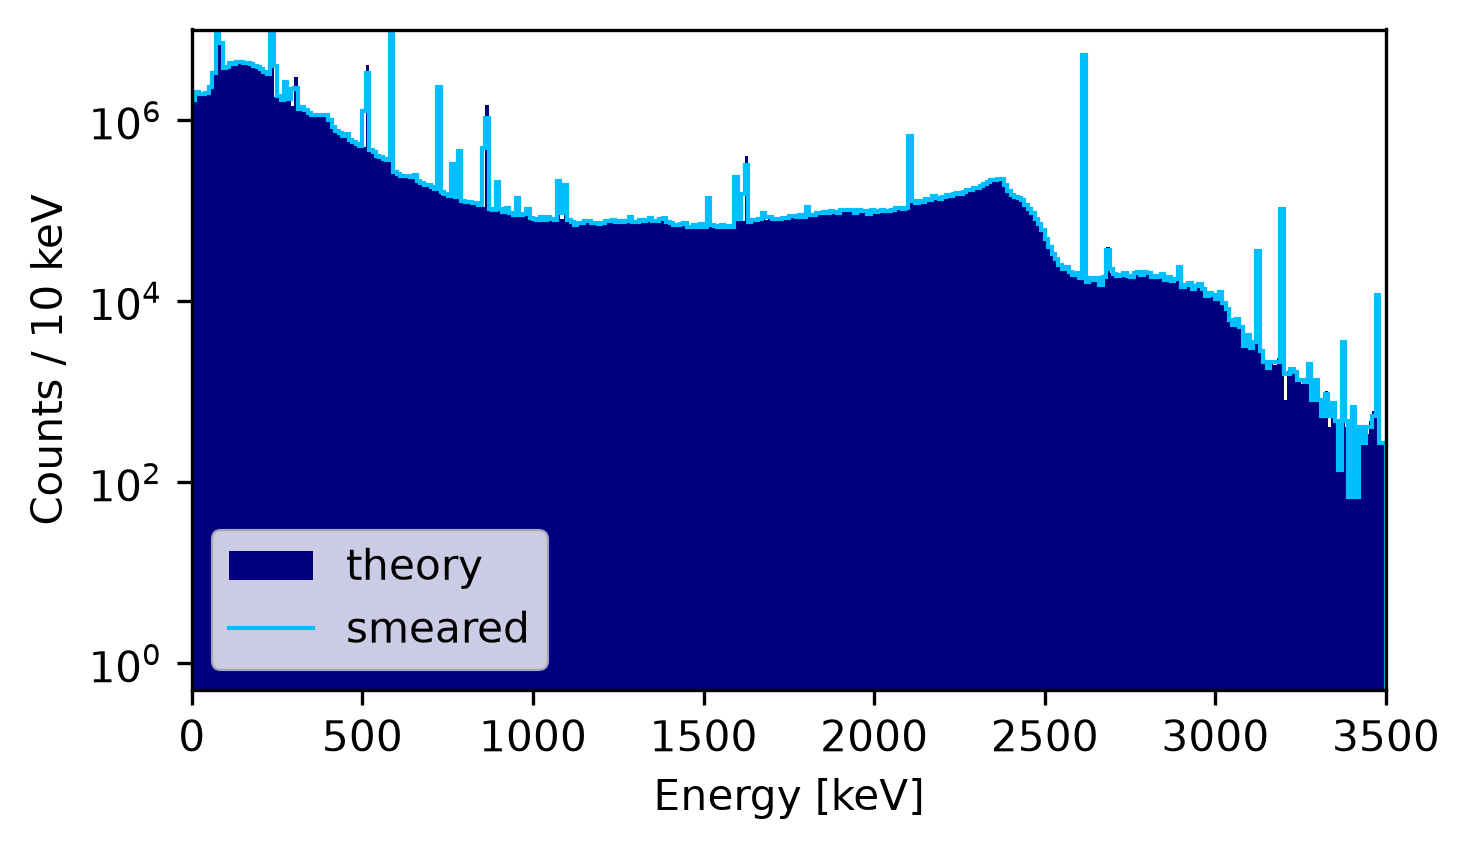

In [40]:
plt.figure(figsize=(5,3), dpi = 300)

plt.stairs(
    counts_theory,
    bins,
    fill = True,
    color="navy",
    label="theory"
)

plt.stairs(
    counts_smeared,
    bins,
    color="deepskyblue",
    label="smeared"
)

plt.xlabel("Energy [keV]")
plt.ylabel(f"Counts / {bins[1]-bins[0]:.0f} keV")
plt.ylim(0.5, 1e7)
plt.yscale("log")
#plt.grid(alpha=0.25)
plt.legend()
plt.xlim(emin, emax)
plt.tight_layout()
plt.show()

# Data comparison

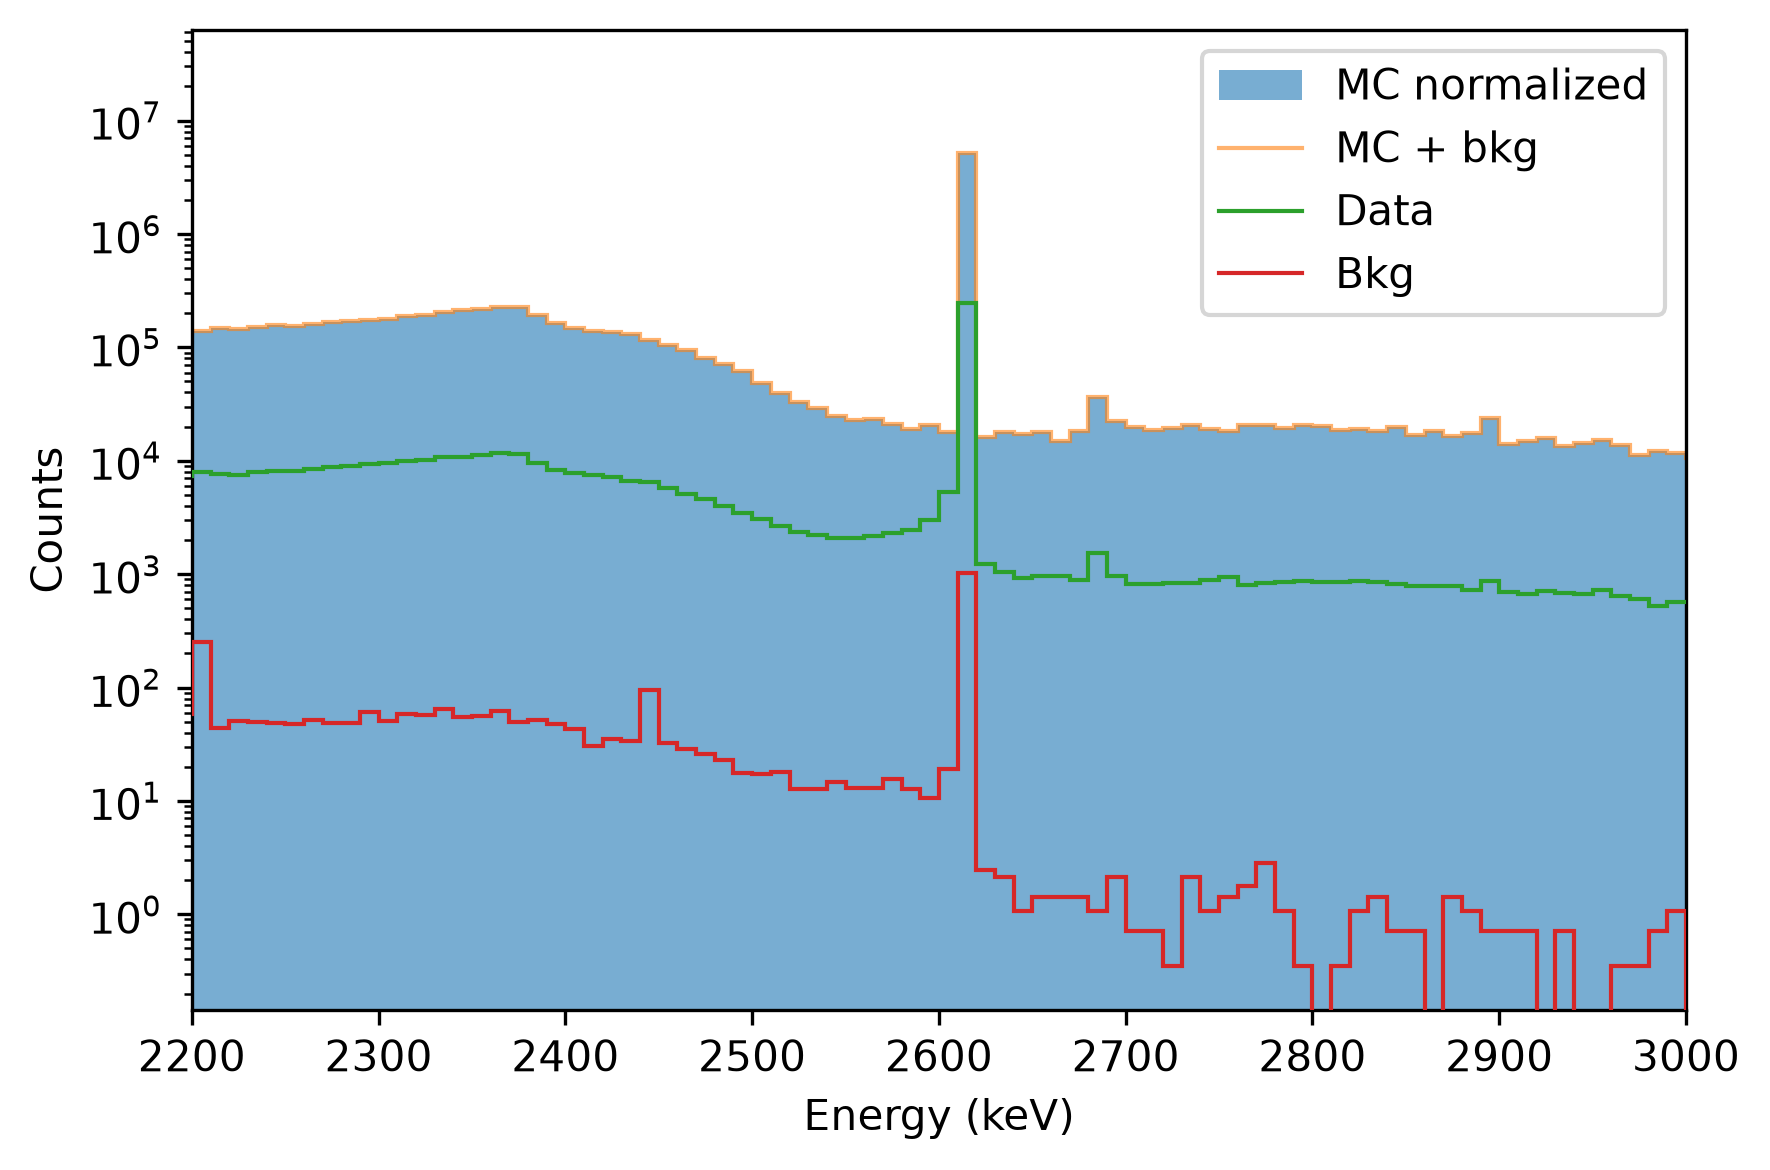

In [41]:

plt.figure(figsize=(6,4), dpi = 300)

plt.stairs(
    counts_MC , 
    bins,
    fill = True,
    alpha = 0.6,
    label="MC normalized"
)

plt.stairs(
    counts_MC + counts_bkg, 
    bins,
    #fill = True,
    alpha = 0.6,
    label="MC + bkg"
)



plt.stairs(
    counts_data,
    bins,
    #fill = True,
    #color="deepskyblue",
    label="Data",
    zorder = 10
)

plt.stairs(
    counts_bkg,
    bins,
    label="Bkg",
    zorder = 10
)



plt.xlim(2200, 3000)
plt.yscale("log")
plt.xlabel("Energy (keV)")
plt.ylabel("Counts")
plt.legend()

#ùplt.vlines(2614, 1, 1e5, color = 'red')

plt.tight_layout()
plt.show()


